# Process myPersonality → Pipeline-Ready Format

Converts `wcpr_mypersonality.csv` into the **same schema** as the Essays dataset.

**Output columns** (identical to `data/split/essays/`):

| Column | Type | Example |
|--------|------|---------|
| `text` | str | `"post1 || post2 || …"` |
| `cEXT … cOPN` | str | `"high"` / `"low"` |
| `label` | str | `"10110"` (EXT·NEU·AGR·CON·OPN, high=1) |

**Steps:** filter [5,50] words → top-50 per author → concat with `||` → encode labels → 80/10/10 split → save 5 files matching `data/split/essays/` exactly.

## 1. Configuration

In [1]:
from pathlib import Path

RAW_PATH      = Path('../../data/raw/wcpr_mypersonality.csv')
INTERIM_DIR   = Path('../../data/interim')
PROCESSED_DIR = Path('../../data/processed')
SPLIT_DIR     = Path('../../data/split/myp')

MIN_WORDS  = 5
MAX_WORDS  = 50
MAX_POSTS  = 50
DELIMITER  = ' || '

# 80 / 10 / 10 -- matches essays split ratio
VAL_SIZE    = 0.1
TEST_SIZE   = 0.1
RANDOM_SEED = 42

LABEL_COLS = ['cEXT', 'cNEU', 'cAGR', 'cCON', 'cOPN']
LABEL_MAP  = {'y': 'high', 'n': 'low'}
SPLIT_COLS = ['text'] + LABEL_COLS + ['label']  # exact essays column order

for d in [INTERIM_DIR, PROCESSED_DIR, SPLIT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Paths ready:')
for name, p in [('interim', INTERIM_DIR), ('processed', PROCESSED_DIR), ('split', SPLIT_DIR)]:
    print(f'  {name:<10}: {p.resolve()}')

Paths ready:
  interim   : F:\std\GR\code\model_x_ocean\data\interim
  processed : F:\std\GR\code\model_x_ocean\data\processed
  split     : F:\std\GR\code\model_x_ocean\data\split\myp


## 2. Load Raw Data

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(RAW_PATH, encoding='latin-1')
df.rename(columns={'#AUTHID': 'author_id'}, inplace=True)
print(f'Raw shape : {df.shape}')
print(f'Authors   : {df["author_id"].nunique()}')
df.head(3)

Raw shape : (9917, 20)
Authors   : 250


,author_id,STATUS,sEXT,sNEU,sAGR,sCON,sOPN,cEXT,cNEU,cAGR,cCON,cOPN,DATE,NETWORKSIZE,BETWEENNESS,NBETWEENNESS,DENSITY,BROKERAGE,NBROKERAGE,TRANSITIVITY
0,b7b7764cfa1c523e4e93ab2a79a946c4,likes the sound of thunder.,2.65,3.0,3.15,3.25,4.4,n,y,n,n,y,06/19/09 03:21 PM,180.0,14861.6,93.29,0.03,15661.0,0.49,0.1
1,b7b7764cfa1c523e4e93ab2a79a946c4,is so sleepy it's not even funny that's she ca...,2.65,3.0,3.15,3.25,4.4,n,y,n,n,y,07/02/09 08:41 AM,180.0,14861.6,93.29,0.03,15661.0,0.49,0.1
2,b7b7764cfa1c523e4e93ab2a79a946c4,is sore and wants the knot of muscles at the b...,2.65,3.0,3.15,3.25,4.4,n,y,n,n,y,06/15/09 01:15 PM,180.0,14861.6,93.29,0.03,15661.0,0.49,0.1


## 3. Compute Word Count

In [3]:
df['word_count'] = df['STATUS'].fillna('').apply(lambda x: len(str(x).split()))
print(df['word_count'].describe().round(2))

count    9917.00
mean       14.53
std        12.46
min         1.00
25%         6.00
50%        11.00
75%        19.00
max        89.00
Name: word_count, dtype: float64


## 4. Filter by Word-Count Window

In [4]:
mask        = (df['word_count'] >= MIN_WORDS) & (df['word_count'] <= MAX_WORDS)
df_filtered = df[mask].copy()
removed = len(df) - len(df_filtered)
print(f'Before : {len(df):,}')
print(f'Removed: {removed:,}  ({removed/len(df)*100:.1f}%)')
print(f'After  : {len(df_filtered):,}  -- authors: {df_filtered["author_id"].nunique()}')

Before : 9,917
Removed: 1,828  (18.4%)
After  : 8,089  -- authors: 244


## 5. Select Top-50 Posts per Author (longest first)

In [5]:
df_selected = (
    df_filtered
    .groupby('author_id', group_keys=False)
    .apply(lambda g: g.sort_values('word_count', ascending=False).head(MAX_POSTS))
    .reset_index(drop=True)
)
print(f'Posts selected : {len(df_selected):,}')
print(f'Authors        : {df_selected["author_id"].nunique()}')

Posts selected : 5,884
Authors        : 244


C:\Users\ASUS\AppData\Local\Temp\ipykernel_23856\2434251050.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sort_values('word_count', ascending=False).head(MAX_POSTS))


## 6. Quality Check

Posts per author:
count    244.00
mean      24.11
std       18.43
min        1.00
25%        7.00
50%       20.00
75%       45.25
max       50.00
Name: post_count, dtype: float64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_23856\422744528.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([df['word_count'], df_selected['word_count']], labels=['All', 'Selected'])


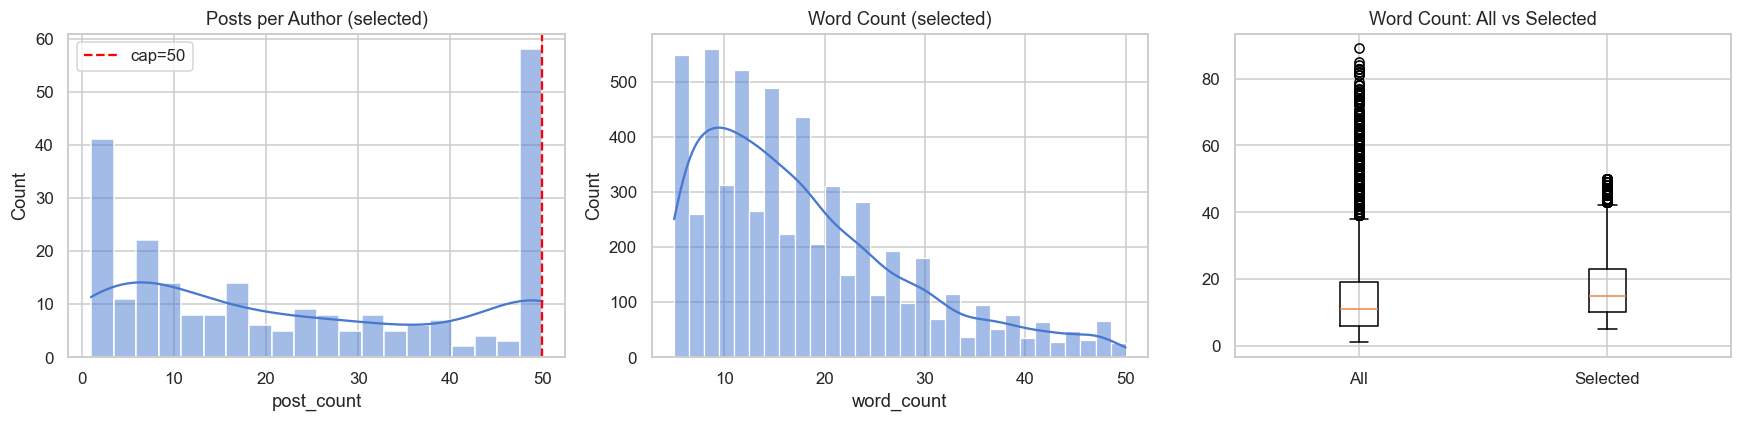

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

posts_per_author = df_selected.groupby('author_id').size().rename('post_count')
print('Posts per author:')
print(posts_per_author.describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(posts_per_author, bins=20, kde=True, ax=axes[0])
axes[0].axvline(MAX_POSTS, color='red', linestyle='--', label=f'cap={MAX_POSTS}')
axes[0].set_title('Posts per Author (selected)')
axes[0].legend()
sns.histplot(df_selected['word_count'], bins=30, kde=True, ax=axes[1])
axes[1].set_title('Word Count (selected)')
axes[2].boxplot([df['word_count'], df_selected['word_count']], labels=['All', 'Selected'])
axes[2].set_title('Word Count: All vs Selected')
plt.tight_layout()
plt.show()

## 7. Per-Author Coverage Report

In [7]:
coverage = pd.concat([
    df.groupby('author_id').size().rename('raw_posts'),
    df_filtered.groupby('author_id').size().rename('filtered_posts'),
    df_selected.groupby('author_id').size().rename('selected_posts'),
], axis=1).fillna(0).astype(int)
coverage['at_cap'] = coverage['selected_posts'] == MAX_POSTS
coverage['filter_loss_pct'] = (
    (coverage['raw_posts'] - coverage['filtered_posts']) / coverage['raw_posts'] * 100
).round(1)
print(f'At {MAX_POSTS}-post cap : {coverage["at_cap"].sum()} authors')
print(f'Below cap     : {(~coverage["at_cap"]).sum()} authors')
print()
print(coverage.sort_values('selected_posts', ascending=False).head(10).to_string())

At 50-post cap : 55 authors
Below cap     : 195 authors

                                  raw_posts  filtered_posts  selected_posts  at_cap  filter_loss_pct
author_id                                                                                           
8d7faa6d7f104a6cb7c4a9e1c6310a15        114              97              50    True             14.9
4b8c9b247d45495cdb1ebf755fcec1f6         95              83              50    True             12.6
c85845b82e705a32f674757d8912df23         93              84              50    True              9.7
5299b573a6caaf4aebfb3cf6bc8acfd8         73              60              50    True             17.8
527ed53d2ba3a3bc417b8402d5b2f556        194             164              50    True             15.5
526ac2635cb3f5e0ee5d7424e83e9107         93              64              50    True             31.2
9f320ade181aa12bf10361871afa8d90         77              71              50    True              7.8
502db2fcfe26705ae16a46c5cb2ad2e5  

## 8. Save Interim Per-Post Artefacts

In [8]:
df_selected.to_csv(INTERIM_DIR / 'selected_posts.csv', index=False)
coverage.to_csv(INTERIM_DIR / 'author_coverage.csv')
per_author_dir = INTERIM_DIR / 'per_author'
per_author_dir.mkdir(exist_ok=True)
for author_id, group in df_selected.groupby('author_id'):
    posts = group.sort_values('word_count', ascending=False)['STATUS'].tolist()
    (per_author_dir / f'{author_id}.txt').write_text('\n\n'.join(posts), encoding='utf-8')
print(f'Saved: data/interim/selected_posts.csv  ({len(df_selected):,} rows)')
print(f'Saved: data/interim/author_coverage.csv')
print(f'Saved: data/interim/per_author/  ({df_selected["author_id"].nunique()} files)')

Saved: data/interim/selected_posts.csv  (5,884 rows)
Saved: data/interim/author_coverage.csv
Saved: data/interim/per_author/  (244 files)


## 9. Build Author-Level Dataset

- `text` -- posts joined with `' || '`
- `cEXT ... cOPN` -- `"high"` / `"low"`
- `label` -- binary string e.g. `"10110"`
- No `author_id` column

In [9]:
text_series = (
    df_selected
    .groupby('author_id')['STATUS']
    .apply(lambda posts: DELIMITER.join(posts.astype(str)))
    .rename('text')
)
enc_labels = df_selected.groupby('author_id')[LABEL_COLS].first().replace(LABEL_MAP)
label_str  = enc_labels.apply(
    lambda row: ''.join('1' if v == 'high' else '0' for v in row), axis=1
).rename('label')

# drop=True on reset_index: author_id stays as index only, never becomes a column
df_out = text_series.to_frame().join(enc_labels).join(label_str).reset_index(drop=True)

print(f'Shape  : {df_out.shape}')
print(f'Columns: {df_out.columns.tolist()}')
df_out.head(3)

Shape  : (244, 7)
Columns: ['text', 'cEXT', 'cNEU', 'cAGR', 'cCON', 'cOPN', 'label']


,text,cEXT,cNEU,cAGR,cCON,cOPN,label
0,Supervisor: *PROPNAME* (second preference) Res...,low,high,low,low,low,01000
1,"Did *PROPNAME* in 16:37, made money in Vegas, ...",high,high,low,high,low,11010
2,"""In awe I watched the waxing moon ride across ...",low,high,high,high,high,01111


In [10]:
# Sanity checks
delim_counts = df_out['text'].str.count(r' \|\| ')
expected     = df_selected.groupby('author_id').size().values - 1
delim_ok     = (delim_counts.values == expected).all()
label_vals   = {col: sorted(df_out[col].unique().tolist()) for col in LABEL_COLS}
len5_ok      = (df_out['label'].str.len() == 5).all()
print(f'Delimiter counts correct : {delim_ok}')
print(f'Label values             : {label_vals}')
print(f'All label strings len=5  : {len5_ok}')

Delimiter counts correct : True
Label values             : {'cEXT': ['high', 'low'], 'cNEU': ['high', 'low'], 'cAGR': ['high', 'low'], 'cCON': ['high', 'low'], 'cOPN': ['high', 'low']}
All label strings len=5  : True


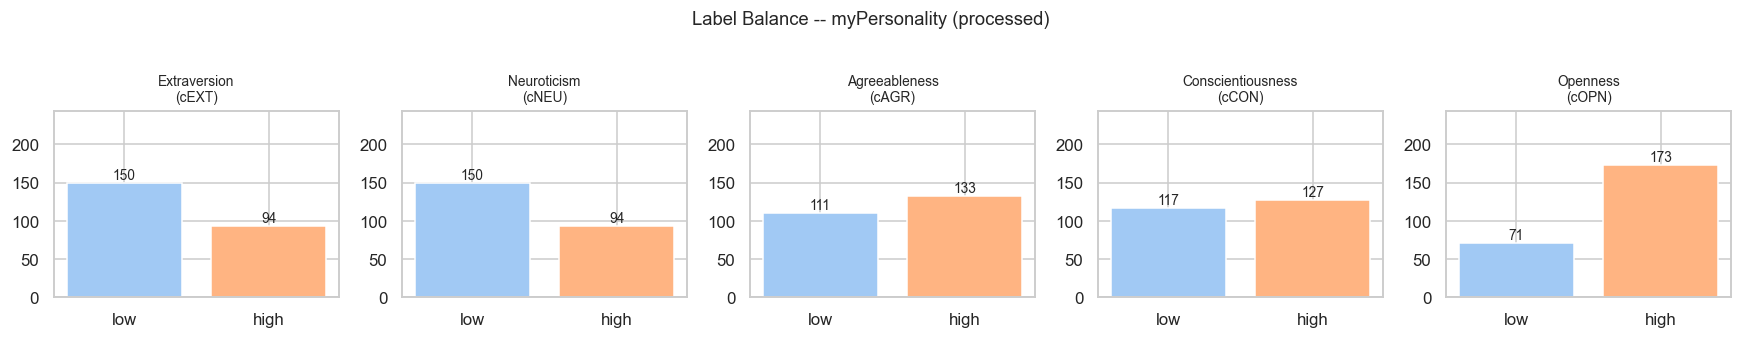

In [11]:
trait_names = ['Extraversion', 'Neuroticism', 'Agreeableness', 'Conscientiousness', 'Openness']
fig, axes = plt.subplots(1, 5, figsize=(16, 3))
for ax, col, name in zip(axes, LABEL_COLS, trait_names):
    counts = df_out[col].value_counts()
    bars = ax.bar(['low', 'high'], [counts.get('low', 0), counts.get('high', 0)],
                  color=sns.color_palette('pastel')[:2])
    ax.set_title(f'{name}\n({col})', fontsize=9)
    ax.set_ylim(0, len(df_out))
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+1,
                int(bar.get_height()), ha='center', va='bottom', fontsize=9)
plt.suptitle('Label Balance -- myPersonality (processed)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 10. Train / Val / Test Split (80/10/10 stratified)

In [12]:
from sklearn.model_selection import train_test_split

# Step 1: identical to before — keeps train exactly the same
train_val_df, _test_df = train_test_split(
    df_out, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=df_out['cOPN']
)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=VAL_SIZE / (1 - TEST_SIZE),
    random_state=RANDOM_SEED,
    stratify=train_val_df['cOPN'],
)

# Step 2: new test = old val + old test (no val split saved)
test_df = pd.concat([val_df, _test_df]).reset_index(drop=True)

train_df = train_df.reset_index(drop=True)

total = len(df_out)
print(f'Total : {total}  |  Train : {len(train_df)} ({len(train_df)/total*100:.0f}%)  |  '
      f'Test : {len(test_df)} ({len(test_df)/total*100:.0f}%)')
print()
print(f"{'Trait':<8}  {'Full':>6}  {'Train':>6}  {'Test':>6}  (% high)")
print('-' * 40)
for col in LABEL_COLS:
    fp = (df_out[col]   == 'high').mean() * 100
    tp = (train_df[col] == 'high').mean() * 100
    ep = (test_df[col]  == 'high').mean() * 100
    print(f'{col:<8}  {fp:>5.1f}%  {tp:>5.1f}%  {ep:>5.1f}%')

Total : 244  |  Train : 194 (80%)  |  Test : 50 (20%)

Trait       Full   Train    Test  (% high)
----------------------------------------
cEXT       38.5%   42.3%   24.0%
cNEU       38.5%   36.1%   48.0%
cAGR       54.5%   53.6%   58.0%
cCON       52.0%   51.5%   54.0%
cOPN       70.9%   70.6%   72.0%


## 11. Save Outputs

In [13]:
df_out.to_csv(PROCESSED_DIR / 'processed_mypersonality_selected.csv', index=False)
print(f'Saved: data/processed/processed_mypersonality_selected.csv  ({len(df_out)} rows)')
print()

train_df[SPLIT_COLS].to_csv(SPLIT_DIR / 'train.csv',      index=False)
test_df[SPLIT_COLS].to_csv( SPLIT_DIR / 'test.csv',        index=False)
test_df[SPLIT_COLS].head(1).to_csv( SPLIT_DIR / 'minor_test.csv', index=False)

print(f'Saved: data/split/myp/train.csv       ({len(train_df)} rows)')
print(f'Saved: data/split/myp/test.csv        ({len(test_df)} rows)')
print(f'Saved: data/split/myp/minor_test.csv  (1 row)')
print(f'Columns: {SPLIT_COLS}')

Saved: data/processed/processed_mypersonality_selected.csv  (244 rows)

Saved: data/split/myp/train.csv       (194 rows)
Saved: data/split/myp/test.csv        (50 rows)
Saved: data/split/myp/minor_test.csv  (1 row)
Columns: ['text', 'cEXT', 'cNEU', 'cAGR', 'cCON', 'cOPN', 'label']


## 12. Schema Compatibility Check

In [14]:
essays_dir = Path('../../data/split/essays')
all_ok = True
for fname in ['train.csv', 'test.csv', 'minor_test.csv']:
    e_cols = pd.read_csv(essays_dir / fname).columns.tolist()
    m_cols = pd.read_csv(SPLIT_DIR  / fname).columns.tolist()
    match  = e_cols == m_cols
    all_ok = all_ok and match
    status = 'OK  ' if match else 'FAIL'
    print(f'  {status}  {fname:<20}  {m_cols}')
print()
if all_ok:
    print('All files match essays schema.')
    print('Switch datasets:')
    print("  DATASET = 'essays'  ->  pd.read_csv('data/split/essays/train.csv')")
    print("  DATASET = 'myp'     ->  pd.read_csv('data/split/myp/train.csv')")
else:
    print('Mismatch detected -- check output above.')

  OK    train.csv             ['text', 'cEXT', 'cNEU', 'cAGR', 'cCON', 'cOPN', 'label']
  OK    test.csv              ['text', 'cEXT', 'cNEU', 'cAGR', 'cCON', 'cOPN', 'label']
  OK    minor_test.csv        ['text', 'cEXT', 'cNEU', 'cAGR', 'cCON', 'cOPN', 'label']

All files match essays schema.
Switch datasets:
  DATASET = 'essays'  ->  pd.read_csv('data/split/essays/train.csv')
  DATASET = 'myp'     ->  pd.read_csv('data/split/myp/train.csv')


## 13. Summary

In [15]:
print('=' * 55)
print('PROCESSING SUMMARY')
print('=' * 55)
print(f'Raw posts               : {len(df):,}')
print(f'After word-count filter : {len(df_filtered):,}  (words in [{MIN_WORDS}, {MAX_WORDS}])')
print(f'After per-author cap    : {len(df_selected):,}  (max {MAX_POSTS}/author)')
print(f'Authors retained        : {df_selected["author_id"].nunique()} / {df["author_id"].nunique()}')
print(f'Avg posts per author    : {posts_per_author.mean():.1f}')
print(f'Avg word count per post : {df_selected["word_count"].mean():.1f}')
print()
print(f'Train / Test            : {len(train_df)} / {len(test_df)}')
print(f'Columns                 : {SPLIT_COLS}')
print()
print('Files saved:')
print(f'  data/interim/selected_posts.csv')
print(f'  data/interim/author_coverage.csv')
print(f'  data/interim/per_author/')
print(f'  data/processed/processed_mypersonality_selected.csv')
print(f'  data/split/myp/  ->  train / test / minor_test .csv')

PROCESSING SUMMARY
Raw posts               : 9,917
After word-count filter : 8,089  (words in [5, 50])
After per-author cap    : 5,884  (max 50/author)
Authors retained        : 244 / 250
Avg posts per author    : 24.1
Avg word count per post : 17.8

Train / Test            : 194 / 50
Columns                 : ['text', 'cEXT', 'cNEU', 'cAGR', 'cCON', 'cOPN', 'label']

Files saved:
  data/interim/selected_posts.csv
  data/interim/author_coverage.csv
  data/interim/per_author/
  data/processed/processed_mypersonality_selected.csv
  data/split/myp/  ->  train / test / minor_test .csv
